# Data and Packages

In [2]:
# Main Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy

# Clustering 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import  mutual_info_score
# Parallel processing 
from joblib import Parallel, delayed

In [3]:
# Time constants
seconds_in_day = 60 * 60 * 24 
minutes_per_week = 7 * 24 * 60 
n_weeks = 8     
eight_seconds_week = n_weeks * minutes_per_week * 60

In [4]:
# k in k-means
k_optimal = 2

In [5]:
# Load data and filter for human users & first 8 weeks of data
df = (
    pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                              'auth_type','logon_type','auth_orientation','outcome'])
    .filter(pl.col('src_user').str.starts_with('U'))
    .filter(pl.col('time') < eight_seconds_week)
    .collect(engine='streaming')
)

In [6]:
# Chosen features
feature_cols = [
    'log_n_events',
    'log_n_distinct_src',
    'log_n_distinct_dest',
    'failure_ratio',
    'c_bar',
    's_bar',
    ]

# Functions

In [7]:
# Build the features dataframe
def build_features(df, agg_minutes):

    agg_seconds = agg_minutes * 60

    return (
        df.lazy()
        .with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day) / seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user', 'bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        ).collect()
        )

In [8]:
def cluster_preprocess(features_df, X_scaled, week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    in_bin = features_df['bucket'].is_between(lb,ub).to_numpy()

    features_week = features_df.filter(in_bin)
    X_scaled_week = X_scaled[in_bin]

    return features_week, X_scaled_week 

In [9]:
# Fit k-means
def fit_kmeans(features_df, X_scaled, week, k):

    features_week, X_scaled_week = cluster_preprocess(features_df, X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (
        features_week.with_columns(pl.Series('cluster', labels))
        .select(['src_user', 'bucket', 'cluster'])
    )

    return week, features_week

In [10]:
# Variation of information
def cluster_entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    return scipy.stats.entropy(counts)
 
def variation_of_information(labels_1, labels_2):
 
    H_1 = cluster_entropy(labels_1)
    H_2 = cluster_entropy(labels_2)
    MI = mutual_info_score(labels_1, labels_2)
 
    return H_1 + H_2 - 2 * MI

In [11]:
def vi_by_week(df, agg_hours, k):
 
    agg_minutes = round(agg_hours * 60)  
 
    global buckets_per_week
    buckets_per_week = minutes_per_week // agg_minutes
 
    # Build features
    features_df = build_features(df, agg_minutes)
 
    # Standardise features
    X = features_df.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
 
    # Cluster each week in parallel
    weekly_results = dict(
        Parallel(n_jobs=-1)(
            delayed(fit_kmeans)(features_df, X_scaled, week, k) for week in range(1, n_weeks + 1)
        )
    )
 
    # VI (clustering stability) scores between consecutive weeks
    VI_scores = {}
 
    for week in range(1, n_weeks):
 
        w_curr = weekly_results[week].with_columns(
            relative_bucket = pl.col('bucket') % buckets_per_week
        )
 
        w_next = weekly_results[week + 1].with_columns(
            relative_bucket = pl.col('bucket') % buckets_per_week
        )
 
        overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')
 
        labels_curr = overlap['cluster'].to_numpy()
        labels_next = overlap['cluster_next'].to_numpy()
 
        VI = variation_of_information(labels_curr, labels_next)
 
        VI = VI / (2 * np.log(k))
 
        VI_scores[(week, week + 1)] = VI
 
    return VI_scores
 

In [14]:
transition_labels = ['1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8']

# 1 Hour

In [38]:
VI_scores_1h = vi_by_week(df, agg_hours=1, k=k_optimal)

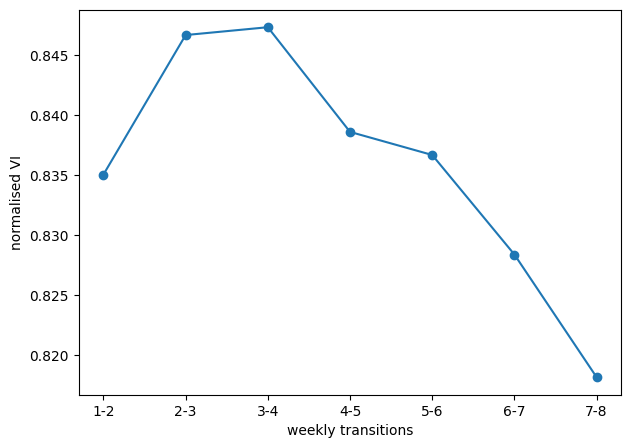

In [39]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_1h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 2 Hours

In [40]:
VI_scores_2h = vi_by_week(df, agg_hours=2, k=k_optimal)

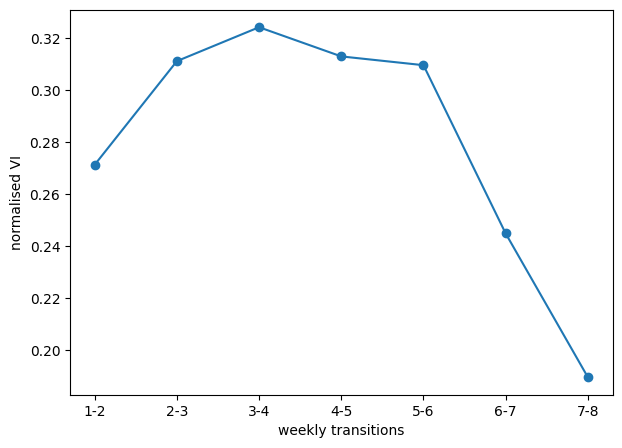

In [41]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_2h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 3 Hours

In [42]:
VI_scores_3h = vi_by_week(df, agg_hours = 3, k=k_optimal)

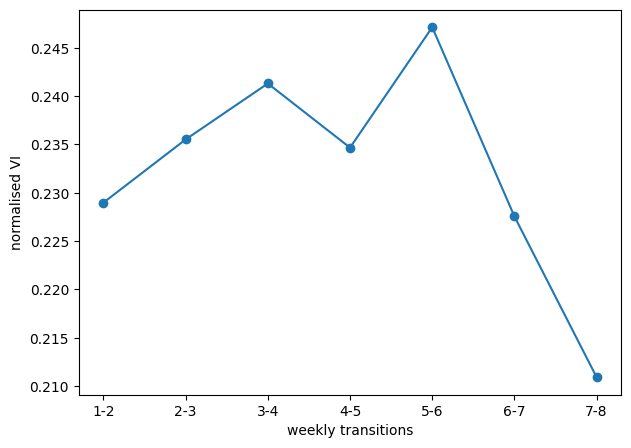

In [43]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_3h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 4 Hours

In [44]:
VI_scores_4h = vi_by_week(df, agg_hours = 4, k=k_optimal)

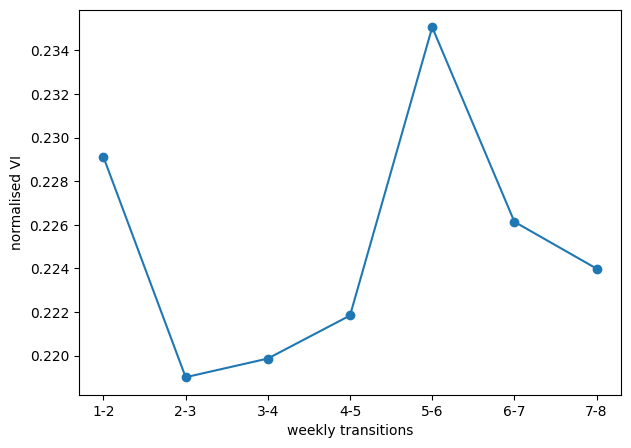

In [45]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_4h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 6 Hours

In [46]:
VI_scores_6h = vi_by_week(df, agg_hours = 6, k=k_optimal)

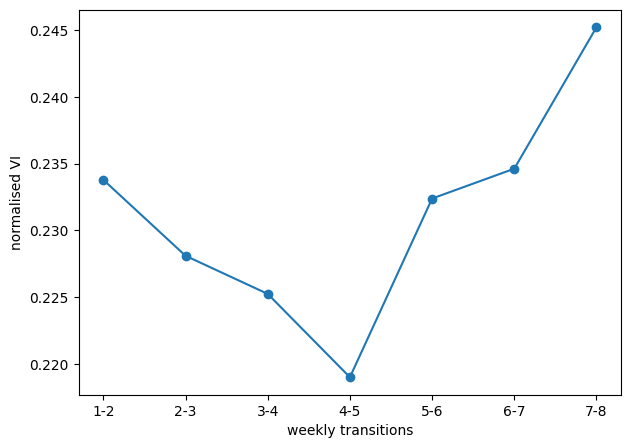

In [47]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_6h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 8 Hours

In [48]:
VI_scores_8h = vi_by_week(df, agg_hours = 8, k=k_optimal)

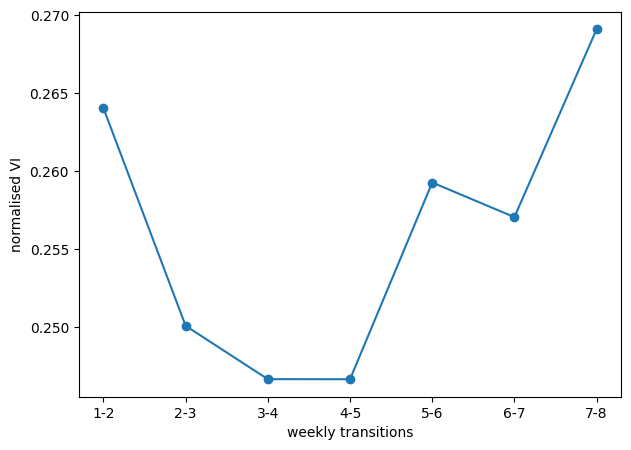

In [49]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_8h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 12 Hours

In [50]:
VI_scores_12h = vi_by_week(df, agg_hours = 12, k=k_optimal)

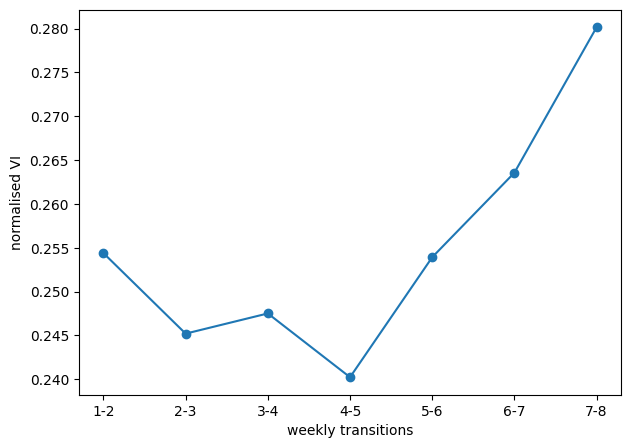

In [51]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_12h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 24 Hours

In [52]:
VI_scores_24h = vi_by_week(df, agg_hours = 24, k=k_optimal)

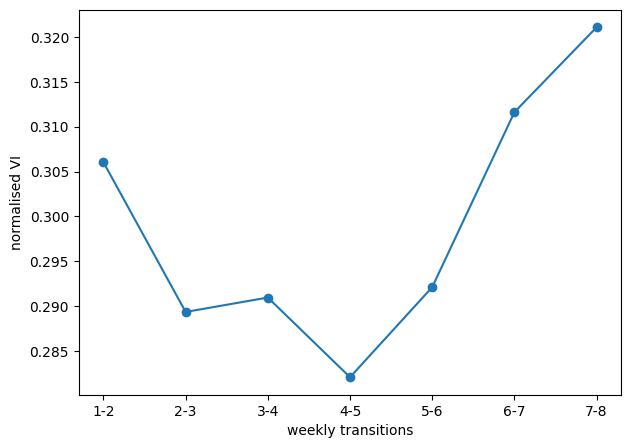

In [53]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_24h.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 1 Minute

In [54]:
VI_scores_1m = vi_by_week(df, agg_hours = 1/60, k=k_optimal)

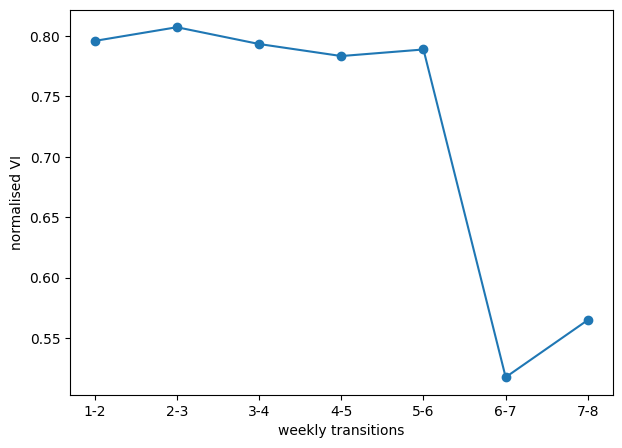

In [55]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_1m.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 10 Minutes

In [56]:
VI_scores_10m = vi_by_week(df, agg_hours = 1/6, k=k_optimal)

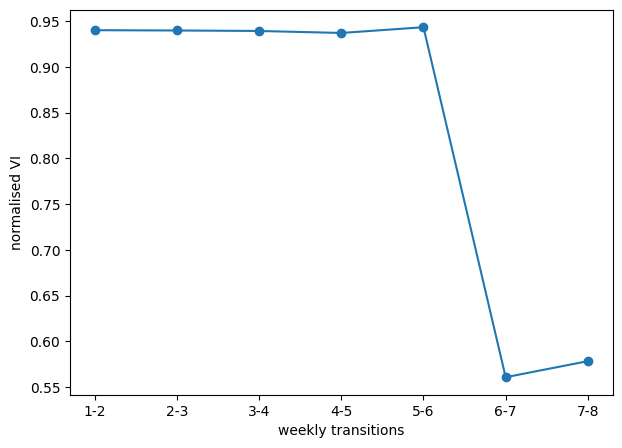

In [57]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_10m.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 30 Minutes

In [58]:
VI_scores_30m = vi_by_week(df, agg_hours = 0.5, k=k_optimal)

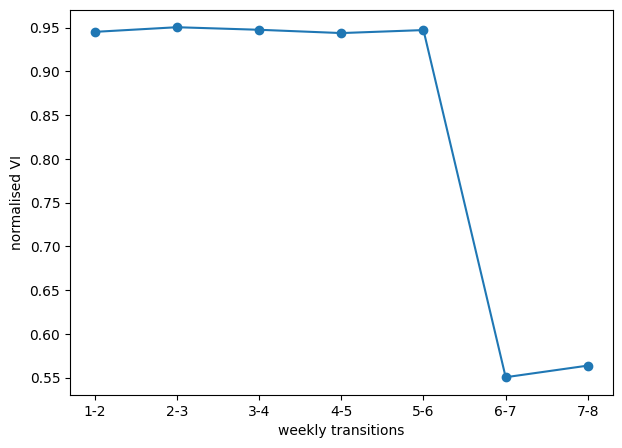

In [59]:
fig, ax = plt.subplots(figsize=(7,5))
 
plt.plot(list(VI_scores_30m.values()), marker='o')
plt.ylabel('normalised VI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

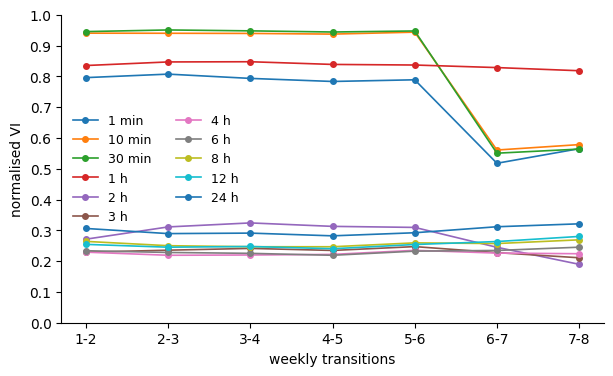

In [60]:
# All VI series, ordered from finest to coarsest aggregation
all_vi = {
    '1 min':  VI_scores_1m,
    '10 min': VI_scores_10m,
    '30 min': VI_scores_30m,
    '1 h':    VI_scores_1h,
    '2 h':    VI_scores_2h,
    '3 h':    VI_scores_3h,
    '4 h':    VI_scores_4h,
    '6 h':    VI_scores_6h,
    '8 h':    VI_scores_8h,
    '12 h':   VI_scores_12h,
    '24 h':   VI_scores_24h,
}
 
# %%
fig, ax = plt.subplots(figsize=(7, 4))
 
for label, vi_scores in all_vi.items():
    ax.plot(list(vi_scores.values()), marker='o', ms=4, lw=1.2, label=label)
 
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_xticks(range(len(transition_labels)))
ax.set_xticklabels(transition_labels)
ax.set_xlabel('weekly transitions')
ax.set_ylabel('normalised VI')
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
 

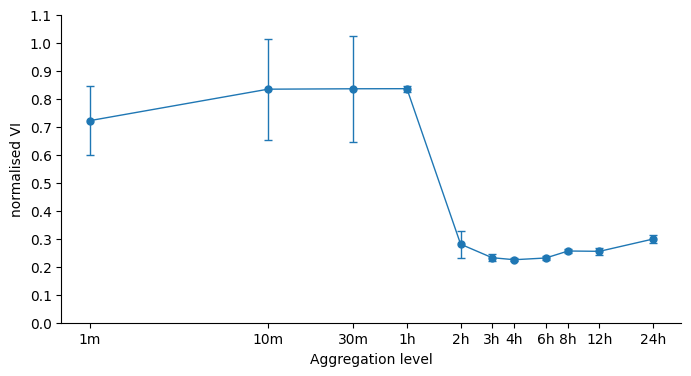

In [66]:
vi_levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
             '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}
 
vi_series = [VI_scores_1m, VI_scores_10m, VI_scores_30m, VI_scores_1h,
             VI_scores_2h, VI_scores_3h, VI_scores_4h, VI_scores_6h,
             VI_scores_8h, VI_scores_12h, VI_scores_24h]
 
# %%
hours = np.array(list(vi_levels.values()))
means = np.array([np.mean(list(s.values())) for s in vi_series])
sds = np.array([np.std(list(s.values()), ddof=1) for s in vi_series])
 
# %%
fig, ax = plt.subplots(figsize=(8, 4))
 
ax.errorbar(hours, means, yerr=sds, marker='o', ms=5, lw=1,
            color='tab:blue', capsize=3, elinewidth=1)
 
ax.set_xscale('log')
ax.set_xticks(hours)
ax.set_xticklabels(['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h'])
ax.minorticks_off()
 
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.2, 0.1))
 
ax.set_xlabel('Aggregation level')
ax.set_ylabel('normalised VI')
ax.spines[['top', 'right']].set_visible(False)